# Economic & Crime Data Analysis
### Unemployment Rate · WTI Crude Oil · Motor Vehicle Theft (1985–2026)

This notebook loads, cleans, and analyzes three datasets:
- **UNRATE** — U.S. Unemployment Rate (FRED, monthly, 1948–2026)
- **MCOILWTICO** — WTI Crude Oil Price (FRED, monthly, 1986–2026)
- **Motor Vehicle Theft** — FBI UCR monthly offenses & clearances (1985–2026)

Sections:
1. Setup & Imports
2. Load & Clean Data
3. Exploratory Statistics
4. Individual Line Graphs
5. Combined & Comparative Charts
6. Inflation-Adjusted Oil Price
7. Correlation Analysis
8. Recession Overlay


## 1. Setup & Imports

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║          PASTE YOUR GITHUB RAW FILE URLs BELOW              ║
# ║  Go to each file on GitHub → click Raw → copy the URL      ║
# ╚══════════════════════════════════════════════════════════════╝

URL_UNRATE = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/UNRATE.csv"

URL_OIL    = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/MCOILWTICO.csv"

URL_THEFT  = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/Motor%20Vehicle%20Theft%20Reported%20by%20Population_04-29-2026%20(1).csv"

# ── Verify the URLs are reachable ─────────────────────────────────────────────
import urllib.request
for name, url in [('UNRATE', URL_UNRATE), ('OIL', URL_OIL), ('THEFT', URL_THEFT)]:
    try:
        code = urllib.request.urlopen(url).getcode()
        print(f"✅  {name}: reachable (HTTP {code})")
    except Exception as e:
        print(f"❌  {name}: FAILED — {e}")


✅  UNRATE: reachable (HTTP 200)
✅  OIL: reachable (HTTP 200)
✅  THEFT: reachable (HTTP 200)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLORS = {
    'unrate': '#e63946',   # red
    'oil':    '#457b9d',   # steel blue
    'theft':  '#2a9d8f',   # teal
    'clear':  '#e9c46a',   # amber
    'real':   '#6a4c93',   # purple (real oil)
}
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Load & Clean Data

In [4]:
# ── 2a. Unemployment Rate ──────────────────────────────────────────────────────
unrate = pd.read_csv(URL_UNRATE, parse_dates=['observation_date'])
unrate.rename(columns={'observation_date': 'date', 'UNRATE': 'unrate'}, inplace=True)
unrate.set_index('date', inplace=True)
unrate.sort_index(inplace=True)

# Drop any rows with missing values
unrate.dropna(inplace=True)

print(f"Unemployment: {unrate.index.min().date()} → {unrate.index.max().date()}  |  {len(unrate):,} rows")
print(unrate.describe().round(2))


Unemployment: 1948-01-01 → 2026-03-01  |  938 rows
       unrate
count  938.00
mean     5.66
std      1.70
min      2.50
25%      4.30
50%      5.50
75%      6.70
max     14.80


In [5]:
# ── 2b. WTI Crude Oil ─────────────────────────────────────────────────────────
oil = pd.read_csv(URL_OIL, parse_dates=['observation_date'])
oil.rename(columns={'observation_date': 'date', 'MCOILWTICO': 'oil_price'}, inplace=True)
oil.set_index('date', inplace=True)
oil.sort_index(inplace=True)

# FRED uses '.' as missing for some months — coerce and drop
oil['oil_price'] = pd.to_numeric(oil['oil_price'], errors='coerce')
n_missing = oil['oil_price'].isna().sum()
oil.dropna(inplace=True)
print(f"Oil: {oil.index.min().date()} → {oil.index.max().date()}  |  {len(oil):,} rows  ({n_missing} dropped)")
print(oil.describe().round(2))


Oil: 1986-01-01 → 2026-03-01  |  483 rows  (0 dropped)
       oil_price
count     483.00
mean       48.24
std        29.33
min        11.35
25%        20.24
50%        42.87
75%        71.22
max       133.88


In [6]:
# ── 2c. Motor Vehicle Theft ───────────────────────────────────────────────────
theft_raw = pd.read_csv(
    URL_THEFT
)

# Separate offenses vs clearances rows
offenses   = theft_raw[theft_raw['Series'].str.contains('Offenses')].copy()
clearances = theft_raw[theft_raw['Series'].str.contains('Clearances')].copy()

def melt_fbi(df, value_name):
    df = df.drop(columns=['Series'])
    df = df.T.reset_index()
    df.columns = ['month_str', value_name]
    df['date'] = pd.to_datetime(df['month_str'], format='%m-%Y')
    df.drop(columns='month_str', inplace=True)
    df[value_name] = pd.to_numeric(df[value_name], errors='coerce')
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    return df

off = melt_fbi(offenses,   'theft_offenses')
clr = melt_fbi(clearances, 'theft_clearances')

theft = off.join(clr, how='inner')
theft.dropna(inplace=True)
# Clearance rate
theft['clearance_rate'] = theft['theft_clearances'] / theft['theft_offenses'] * 100

print(f"Theft: {theft.index.min().date()} → {theft.index.max().date()}  |  {len(theft):,} rows")
print(theft.describe().round(1))


Theft: 1985-01-01 → 2026-03-01  |  495 rows
       theft_offenses  theft_clearances  clearance_rate
count           495.0             495.0           495.0
mean          87858.6           11178.0            12.5
std           30657.9            4794.4             1.9
min            1919.0             205.0             7.8
25%           60595.5            7026.5            11.3
50%           86440.0           10576.0            12.6
75%          104877.0           14886.5            13.6
max          222275.0           31529.0            28.2


## 3. Exploratory Statistics

In [7]:
# ── Quick summary table ────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Variable': ['Unemployment Rate (%)', 'WTI Oil Price ($/bbl)', 
                 'Motor Vehicle Thefts', 'Clearance Rate (%)'],
    'Start':    [unrate.index.min().strftime('%Y-%m'),
                 oil.index.min().strftime('%Y-%m'),
                 theft.index.min().strftime('%Y-%m'),
                 theft.index.min().strftime('%Y-%m')],
    'End':      [unrate.index.max().strftime('%Y-%m'),
                 oil.index.max().strftime('%Y-%m'),
                 theft.index.max().strftime('%Y-%m'),
                 theft.index.max().strftime('%Y-%m')],
    'Min':      [unrate['unrate'].min(),   oil['oil_price'].min(),
                 theft['theft_offenses'].min(), theft['clearance_rate'].min()],
    'Max':      [unrate['unrate'].max(),   oil['oil_price'].max(),
                 theft['theft_offenses'].max(), theft['clearance_rate'].max()],
    'Mean':     [unrate['unrate'].mean(),  oil['oil_price'].mean(),
                 theft['theft_offenses'].mean(), theft['clearance_rate'].mean()],
    'Std':      [unrate['unrate'].std(),   oil['oil_price'].std(),
                 theft['theft_offenses'].std(), theft['clearance_rate'].std()],
}).round(2)

print(summary.to_string(index=False))


             Variable   Start     End     Min       Max     Mean      Std
Unemployment Rate (%) 1948-01 2026-03    2.50     14.80     5.66     1.70
WTI Oil Price ($/bbl) 1986-01 2026-03   11.35    133.88    48.24    29.33
 Motor Vehicle Thefts 1985-01 2026-03 1919.00 222275.00 87858.60 30657.90
   Clearance Rate (%) 1985-01 2026-03    7.82     28.24    12.48     1.87


In [8]:
# ── Annual averages ────────────────────────────────────────────────────────────
unrate_ann  = unrate.resample('YE').mean().rename(columns={'unrate': 'Unemployment (%)'})
oil_ann     = oil.resample('YE').mean().rename(columns={'oil_price': 'Oil ($/bbl)'})
theft_ann   = theft[['theft_offenses','clearance_rate']].resample('YE').mean()

# Find notable years
print("Peak unemployment years:")
print(unrate_ann.nlargest(5, 'Unemployment (%)'))

print("\nPeak oil price years:")
print(oil_ann.nlargest(5, 'Oil ($/bbl)'))

print("\nPeak theft offense years:")
print(theft_ann.nlargest(5, 'theft_offenses'))


Peak unemployment years:
            Unemployment (%)
date                        
1982-12-31          9.708333
2010-12-31          9.608333
1983-12-31          9.600000
2009-12-31          9.283333
2011-12-31          8.933333

Peak oil price years:
            Oil ($/bbl)
date                   
2008-12-31    99.571667
2013-12-31    97.905833
2011-12-31    94.874167
2022-12-31    94.786667
2012-12-31    94.110833

Peak theft offense years:
            theft_offenses  clearance_rate
date                                      
1991-12-31   134917.583333       13.313684
1990-12-31   132756.250000       14.464363
1992-12-31   130980.750000       13.666531
1989-12-31   127240.416667       13.686485
1993-12-31   124711.166667       13.310474


## 4. Individual Line Graphs

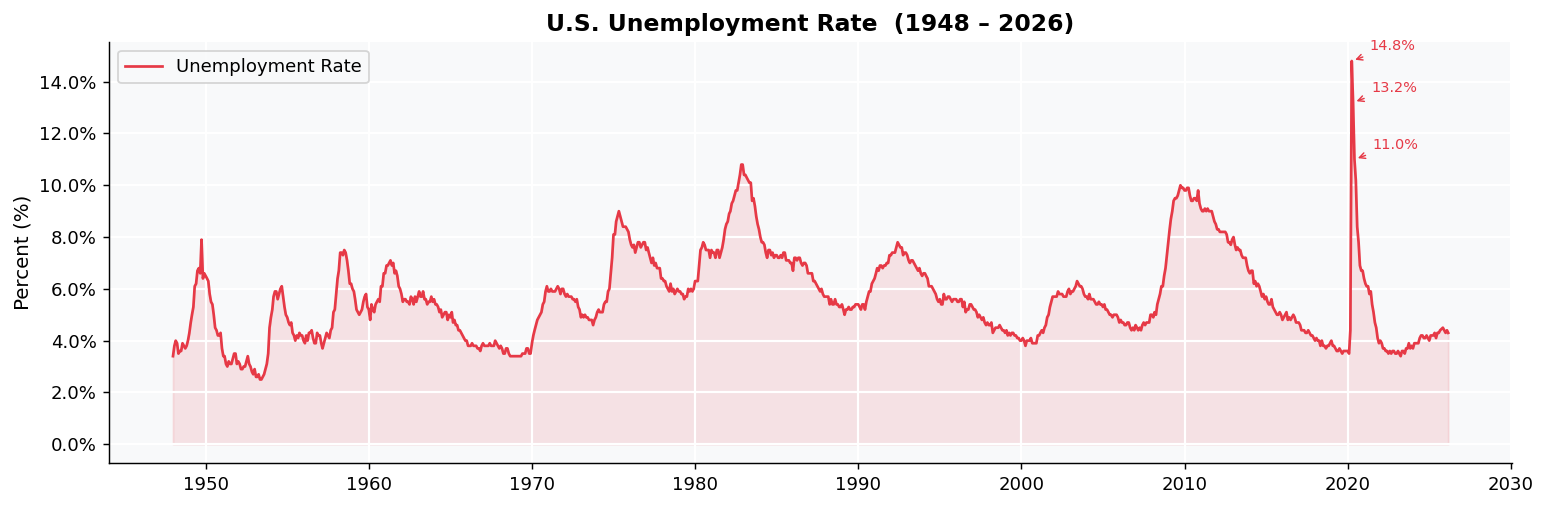

In [9]:
# ── 4a. Unemployment Rate ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(unrate.index, unrate['unrate'], color=COLORS['unrate'], lw=1.5, label='Unemployment Rate')
ax.fill_between(unrate.index, unrate['unrate'], alpha=0.12, color=COLORS['unrate'])

# Annotate notable peaks
peaks = unrate['unrate'].nlargest(3)
for dt, val in peaks.items():
    ax.annotate(f'{val:.1f}%', xy=(dt, val), xytext=(10, 6),
                textcoords='offset points', fontsize=8, color=COLORS['unrate'],
                arrowprops=dict(arrowstyle='->', color=COLORS['unrate'], lw=0.8))

ax.set_title('U.S. Unemployment Rate  (1948 – 2026)', fontweight='bold')
ax.set_ylabel('Percent (%)')
ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


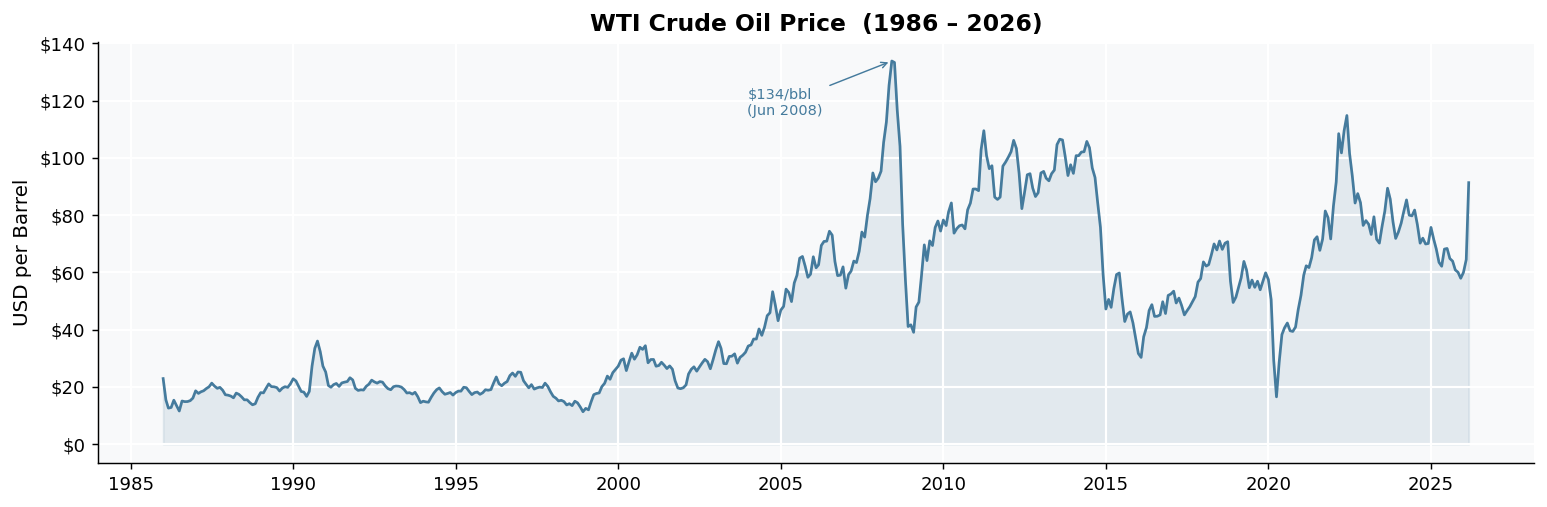

In [10]:
# ── 4b. WTI Crude Oil Price ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(oil.index, oil['oil_price'], color=COLORS['oil'], lw=1.5)
ax.fill_between(oil.index, oil['oil_price'], alpha=0.12, color=COLORS['oil'])

peak_oil = oil['oil_price'].idxmax()
ax.annotate(f"${oil['oil_price'].max():.0f}/bbl\n({peak_oil.strftime('%b %Y')})",
            xy=(peak_oil, oil['oil_price'].max()),
            xytext=(-80, -30), textcoords='offset points', fontsize=8,
            color=COLORS['oil'],
            arrowprops=dict(arrowstyle='->', color=COLORS['oil'], lw=0.8))

ax.set_title('WTI Crude Oil Price  (1986 – 2026)', fontweight='bold')
ax.set_ylabel('USD per Barrel')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
plt.tight_layout()
plt.show()


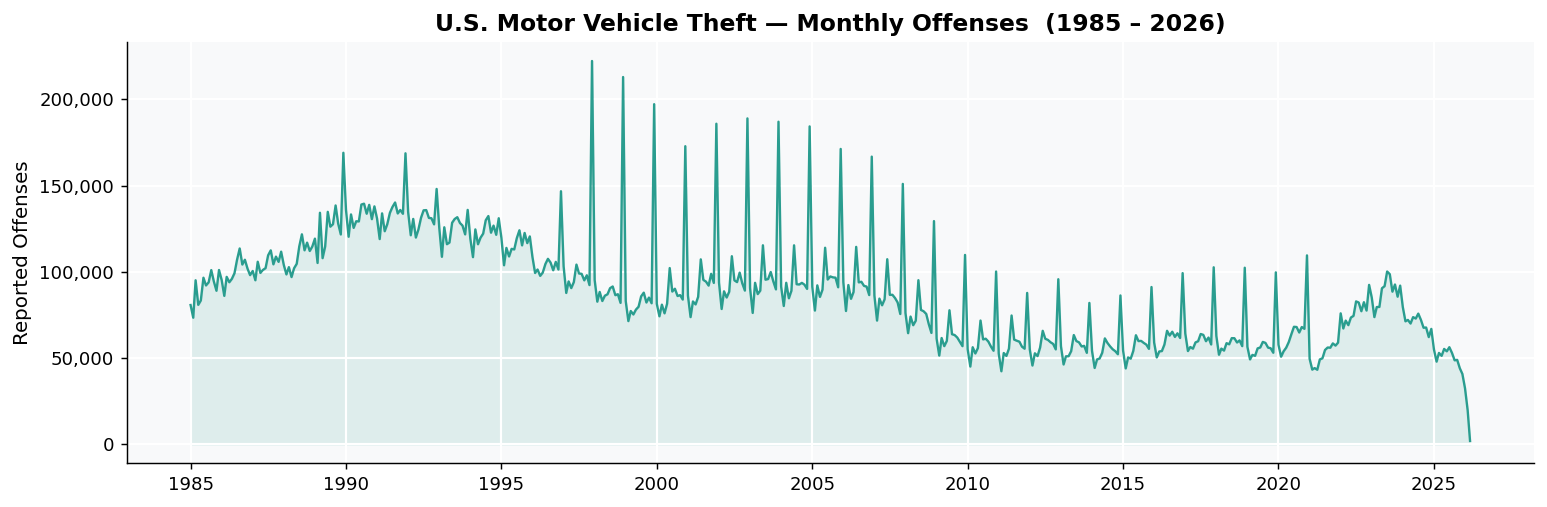

In [11]:
# ── 4c. Motor Vehicle Theft Offenses ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(theft.index, theft['theft_offenses'], color=COLORS['theft'], lw=1.3)
ax.fill_between(theft.index, theft['theft_offenses'], alpha=0.12, color=COLORS['theft'])

ax.set_title('U.S. Motor Vehicle Theft — Monthly Offenses  (1985 – 2026)', fontweight='bold')
ax.set_ylabel('Reported Offenses')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


## 5. Combined & Comparative Charts

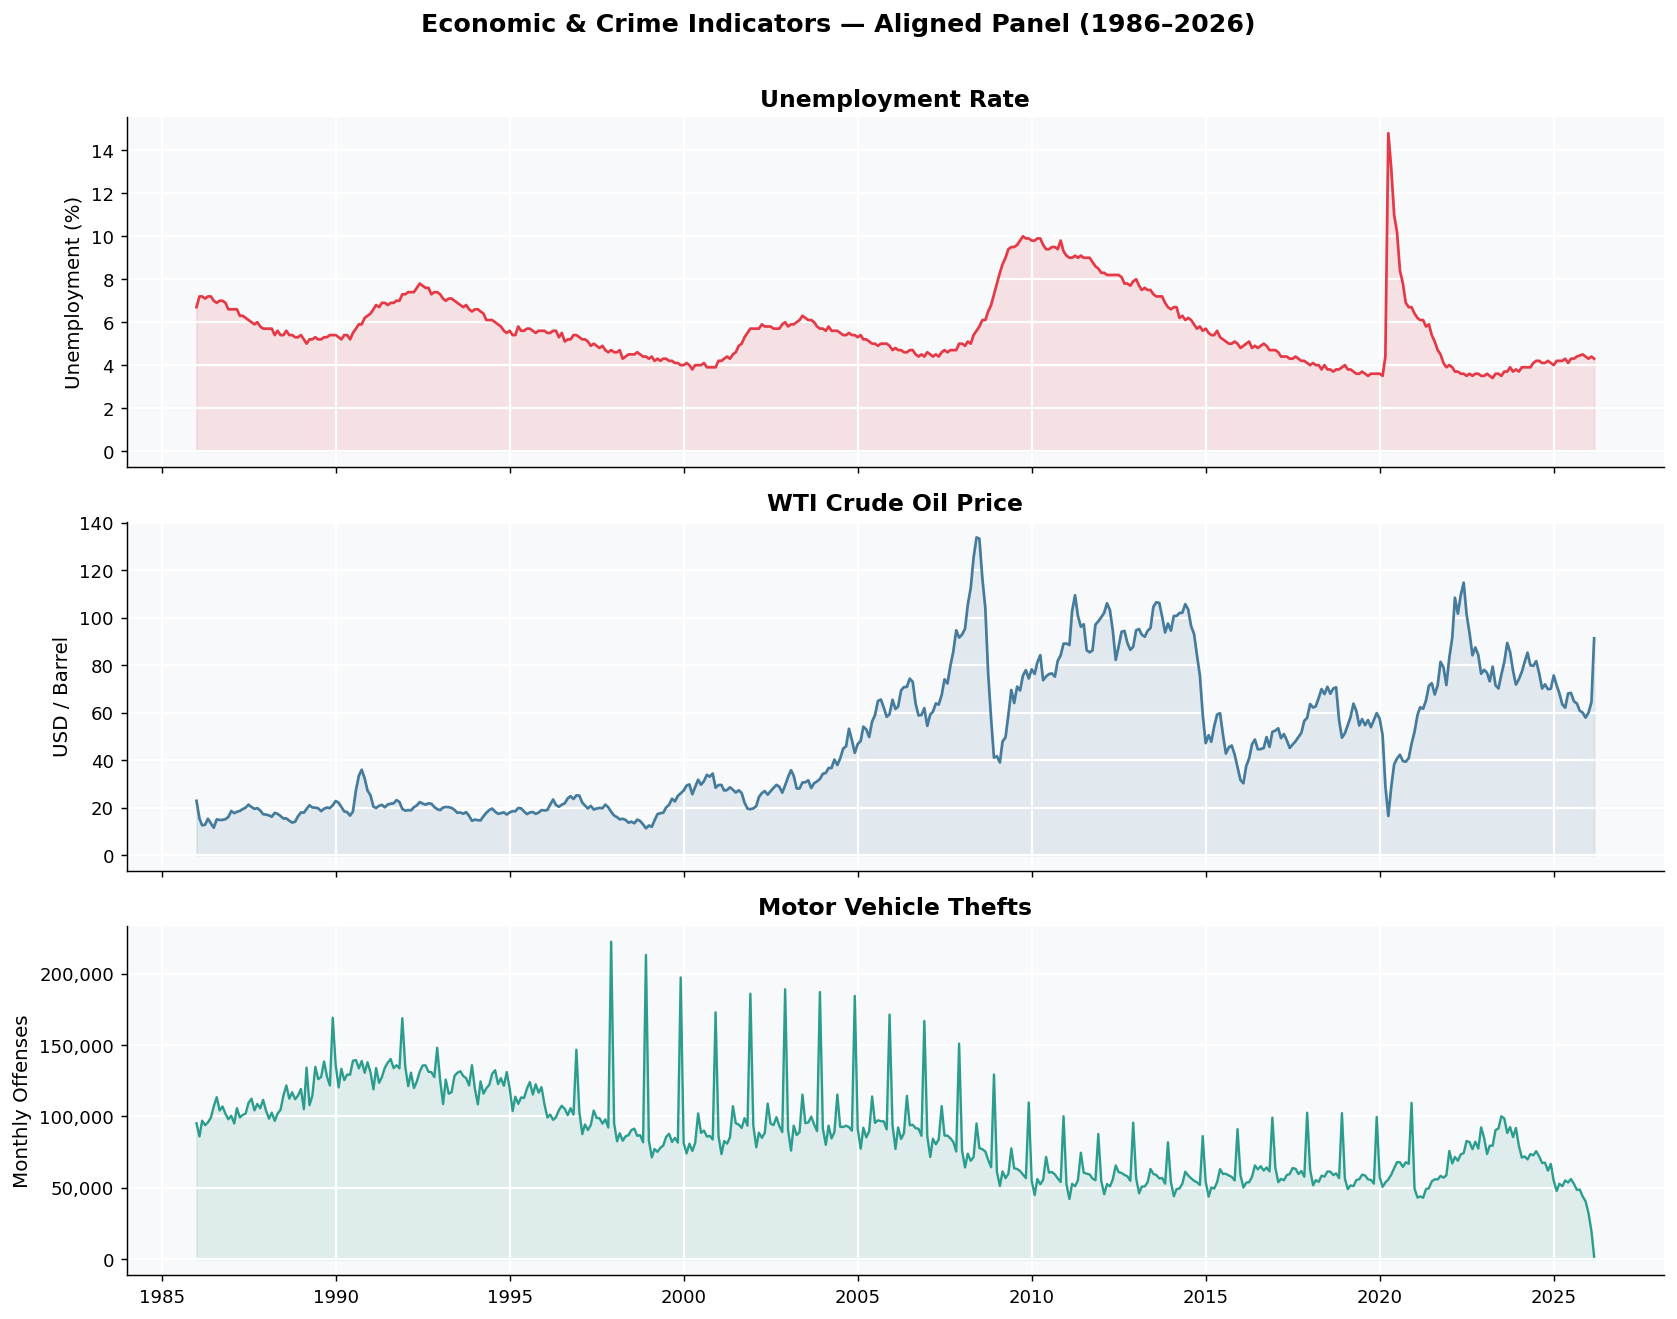

In [13]:
# ── 5a. All three variables — dual-axis panel ─────────────────────────────────
# Align to overlap period (1986 onward) for fair comparison
start = '1986-01-01'
u = unrate.loc[start:]
o = oil.loc[start:]
t = theft.loc[start:]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(u.index, u['unrate'], color=COLORS['unrate'], lw=1.5)
axes[0].fill_between(u.index, u['unrate'], alpha=0.12, color=COLORS['unrate'])
axes[0].set_ylabel('Unemployment (%)')
axes[0].set_title('Unemployment Rate', fontweight='bold')

axes[1].plot(o.index, o['oil_price'], color=COLORS['oil'], lw=1.5)
axes[1].fill_between(o.index, o['oil_price'], alpha=0.12, color=COLORS['oil'])
axes[1].set_ylabel('USD / Barrel')
axes[1].set_title('WTI Crude Oil Price', fontweight='bold')

axes[2].plot(t.index, t['theft_offenses'], color=COLORS['theft'], lw=1.3)
axes[2].fill_between(t.index, t['theft_offenses'], alpha=0.12, color=COLORS['theft'])
axes[2].set_ylabel('Monthly Offenses')
axes[2].set_title('Motor Vehicle Thefts', fontweight='bold')

axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

fig.suptitle('Economic & Crime Indicators — Aligned Panel (1986–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


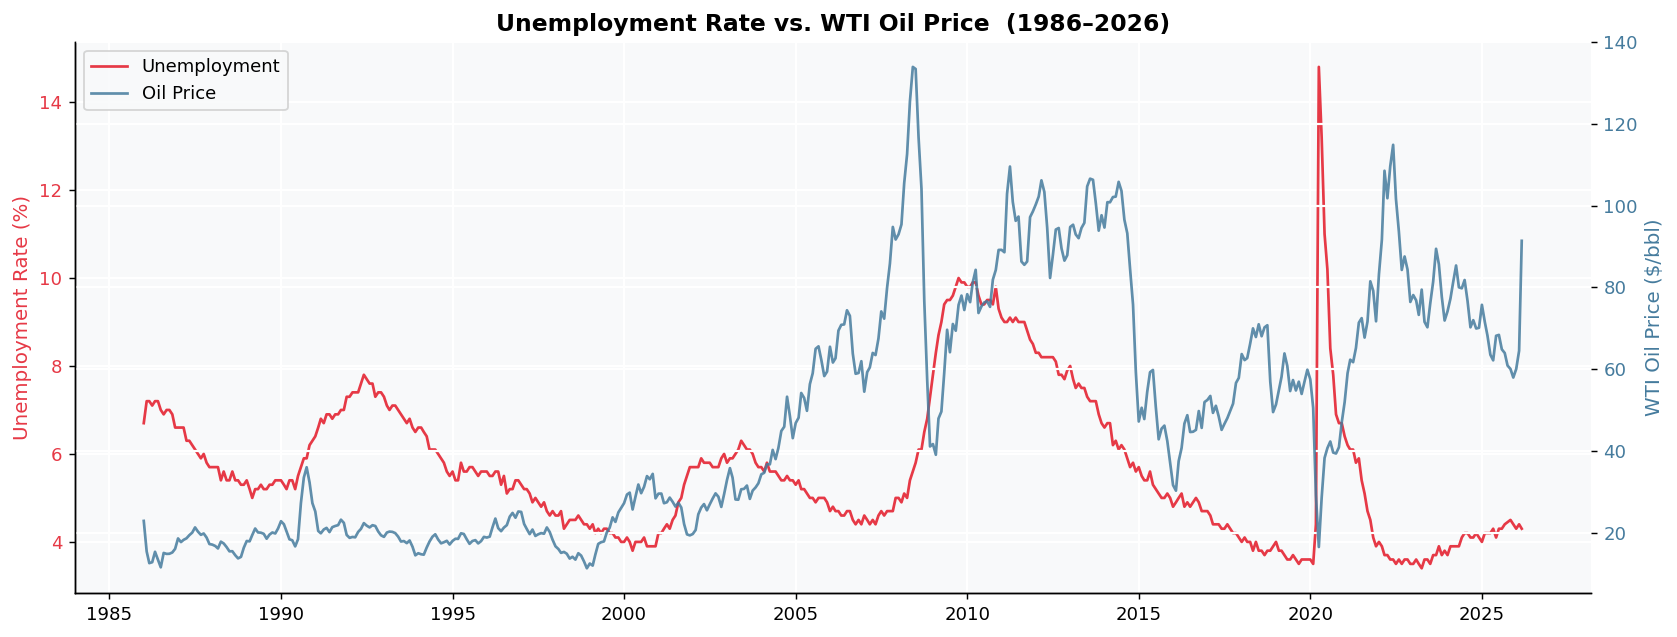

In [14]:
# ── 5b. Unemployment vs. Oil on dual y-axes ───────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.set_ylabel('Unemployment Rate (%)', color=COLORS['unrate'])
l1, = ax1.plot(u.index, u['unrate'], color=COLORS['unrate'], lw=1.5, label='Unemployment')
ax1.tick_params(axis='y', labelcolor=COLORS['unrate'])

ax2 = ax1.twinx()
ax2.set_ylabel('WTI Oil Price ($/bbl)', color=COLORS['oil'])
l2, = ax2.plot(o.index, o['oil_price'], color=COLORS['oil'], lw=1.5, label='Oil Price', alpha=0.85)
ax2.tick_params(axis='y', labelcolor=COLORS['oil'])

ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_title('Unemployment Rate vs. WTI Oil Price  (1986–2026)', fontweight='bold')
ax1.legend(handles=[l1, l2], loc='upper left')
plt.tight_layout()
plt.show()


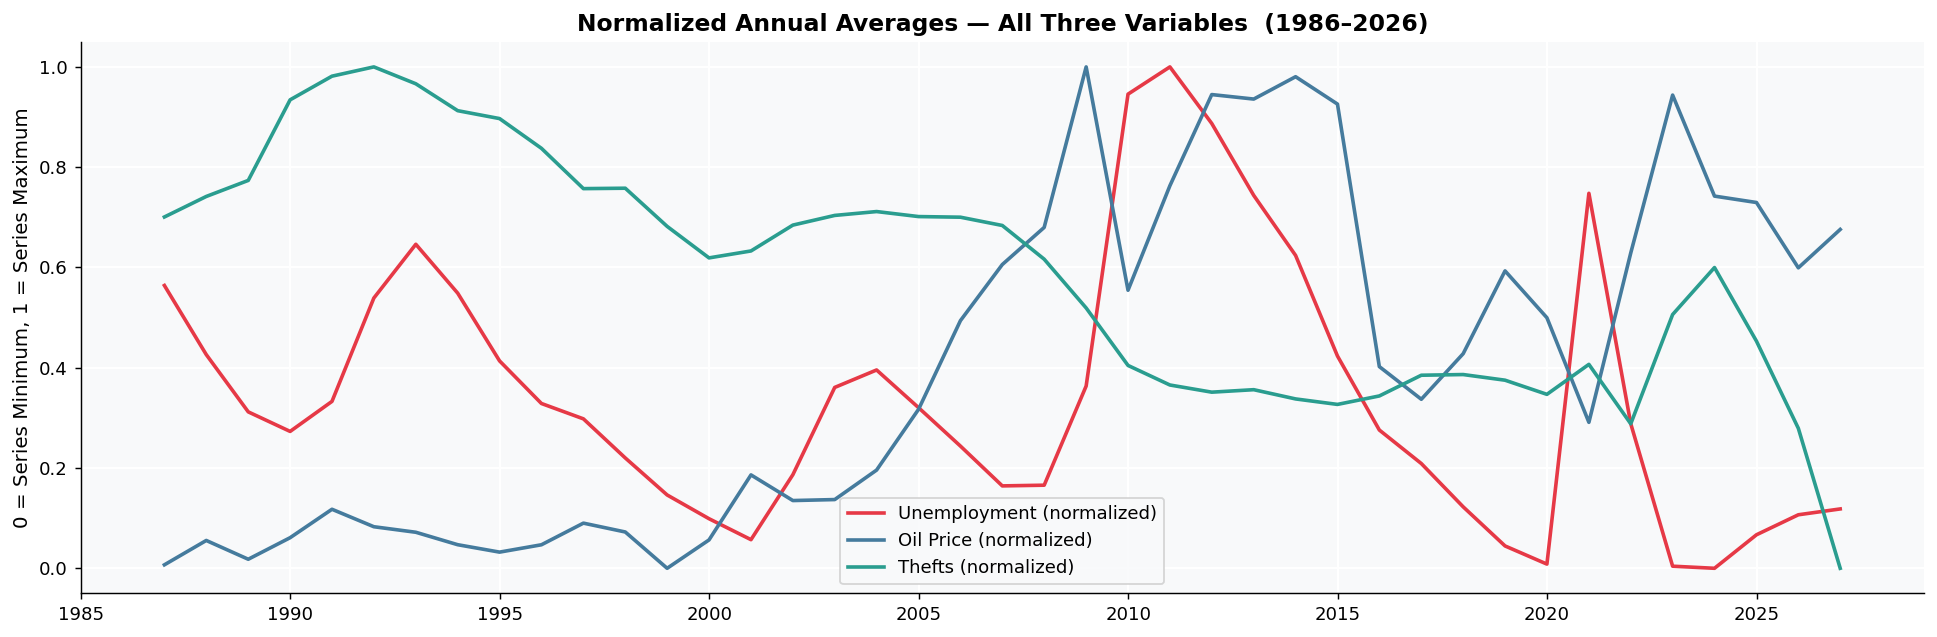

In [15]:
# ── 5c. Annual averages comparison bar chart ──────────────────────────────────
# Resample to annual, normalize each series to 0–1 for visual comparison
common_start = '1986'
u_ann = unrate.loc[common_start:].resample('YE').mean()
o_ann = oil.loc[common_start:].resample('YE').mean()
t_ann = theft.loc[common_start:]['theft_offenses'].resample('YE').mean()

def norm(s): return (s - s.min()) / (s.max() - s.min())

fig, ax = plt.subplots(figsize=(15, 5))
years = u_ann.index

ax.plot(years, norm(u_ann['unrate']),   color=COLORS['unrate'], lw=2,   label='Unemployment (normalized)')
ax.plot(years, norm(o_ann['oil_price']), color=COLORS['oil'],   lw=2,   label='Oil Price (normalized)')
ax.plot(years, norm(t_ann),             color=COLORS['theft'],  lw=2,   label='Thefts (normalized)')

ax.set_title('Normalized Annual Averages — All Three Variables  (1986–2026)',
             fontweight='bold')
ax.set_ylabel('0 = Series Minimum, 1 = Series Maximum')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


## 6. Inflation-Adjusted Oil Price

We approximate real (inflation-adjusted) oil prices using the **CPI** ratio method.  
Since we don't load the CPI dataset here, we use a widely-published average annual  
CPI series (BLS data through 2024, extrapolated to 2025–2026) to deflate nominal prices  
to **constant 2024 dollars**.


In [16]:
# ── Annual CPI (BLS, 1986–2026 approximate) ──────────────────────────────────
cpi_annual = {
    1986:109.6, 1987:113.6, 1988:118.3, 1989:124.0, 1990:130.7,
    1991:136.2, 1992:140.3, 1993:144.5, 1994:148.2, 1995:152.4,
    1996:156.9, 1997:160.5, 1998:163.0, 1999:166.6, 2000:172.2,
    2001:177.1, 2002:179.9, 2003:184.0, 2004:188.9, 2005:195.3,
    2006:201.6, 2007:207.3, 2008:215.3, 2009:214.5, 2010:218.1,
    2011:224.9, 2012:229.6, 2013:233.0, 2014:236.7, 2015:237.0,
    2016:240.0, 2017:245.1, 2018:251.1, 2019:255.7, 2020:258.8,
    2021:270.9, 2022:292.7, 2023:304.7, 2024:314.2, 2025:319.5,
    2026:322.0,
}
cpi_base = cpi_annual[2024]   # deflate to 2024 dollars

oil_real = oil.copy()
oil_real['cpi'] = oil_real.index.year.map(cpi_annual)
oil_real['oil_real'] = oil_real['oil_price'] * (cpi_base / oil_real['cpi'])

print("Sample — nominal vs real (2024$):")
print(oil_real[['oil_price', 'cpi', 'oil_real']].sample(10, random_state=42).sort_index().round(2))


Sample — nominal vs real (2024$):
            oil_price    cpi  oil_real
date                                  
1998-05-01      14.91  163.0     28.74
2001-02-01      29.61  177.1     52.53
2004-12-01      43.15  188.9     71.77
2010-10-01      81.89  218.1    117.97
2017-08-01      48.04  245.1     61.58
2020-10-01      39.40  258.8     47.83
2020-12-01      47.02  258.8     57.09
2023-02-01      76.83  304.7     79.23
2025-06-01      68.17  319.5     67.04
2025-11-01      60.06  319.5     59.06


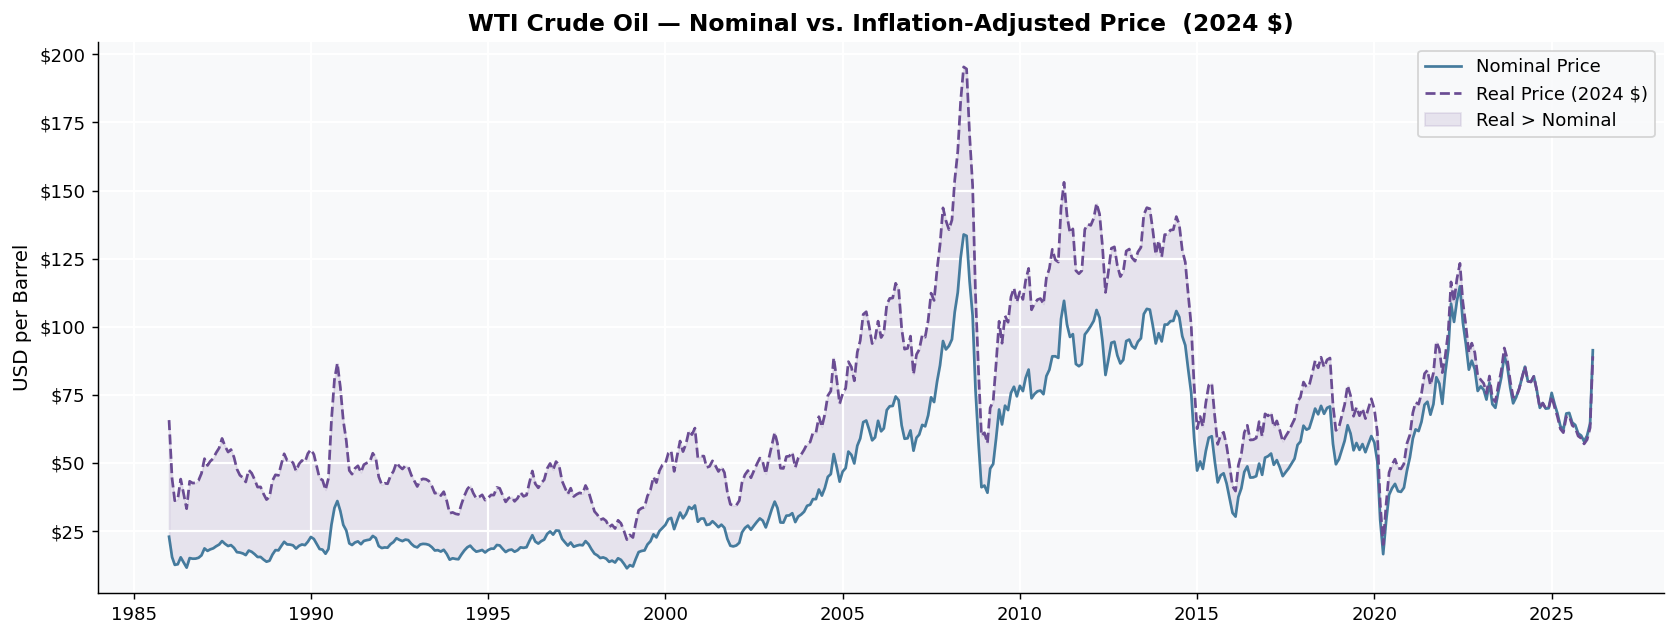


Nominal peak:  $133.88  (Jun 2008)
Real peak:     $195.38  (Jun 2008)


In [17]:
# ── Plot nominal vs real oil price ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(oil_real.index, oil_real['oil_price'], color=COLORS['oil'],  lw=1.5,
        label='Nominal Price')
ax.plot(oil_real.index, oil_real['oil_real'],  color=COLORS['real'], lw=1.5,
        linestyle='--', label='Real Price (2024 $)')

ax.fill_between(oil_real.index,
                oil_real['oil_price'], oil_real['oil_real'],
                where=oil_real['oil_real'] >= oil_real['oil_price'],
                alpha=0.12, color=COLORS['real'], label='Real > Nominal')
ax.fill_between(oil_real.index,
                oil_real['oil_price'], oil_real['oil_real'],
                where=oil_real['oil_real'] < oil_real['oil_price'],
                alpha=0.12, color=COLORS['oil'])

ax.set_title('WTI Crude Oil — Nominal vs. Inflation-Adjusted Price  (2024 $)', fontweight='bold')
ax.set_ylabel('USD per Barrel')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nNominal peak:  ${oil_real['oil_price'].max():.2f}  ({oil_real['oil_price'].idxmax().strftime('%b %Y')})")
print(f"Real peak:     ${oil_real['oil_real'].max():.2f}  ({oil_real['oil_real'].idxmax().strftime('%b %Y')})")


## 7. Correlation Analysis

In [18]:
# Merge all series to overlapping monthly dates
merged = (
    unrate
    .join(oil_real[['oil_price','oil_real']], how='inner')
    .join(theft[['theft_offenses','clearance_rate']], how='inner')
)
merged.dropna(inplace=True)
print(f"Merged dataset: {merged.index.min().date()} → {merged.index.max().date()}  |  {len(merged):,} rows")
merged.head()


Merged dataset: 1986-01-01 → 2026-03-01  |  482 rows


,unrate,oil_price,oil_real,theft_offenses,clearance_rate
date,,,,,
1986-01-01,6.7,22.93,65.735456,95257,14.100801
1986-02-01,7.2,15.46,44.320547,86045,14.818990
1986-03-01,7.2,12.61,36.150201,97068,14.893683
1986-04-01,7.1,12.84,36.809562,93947,15.389528
1986-05-01,7.2,15.38,44.091204,95912,14.886563


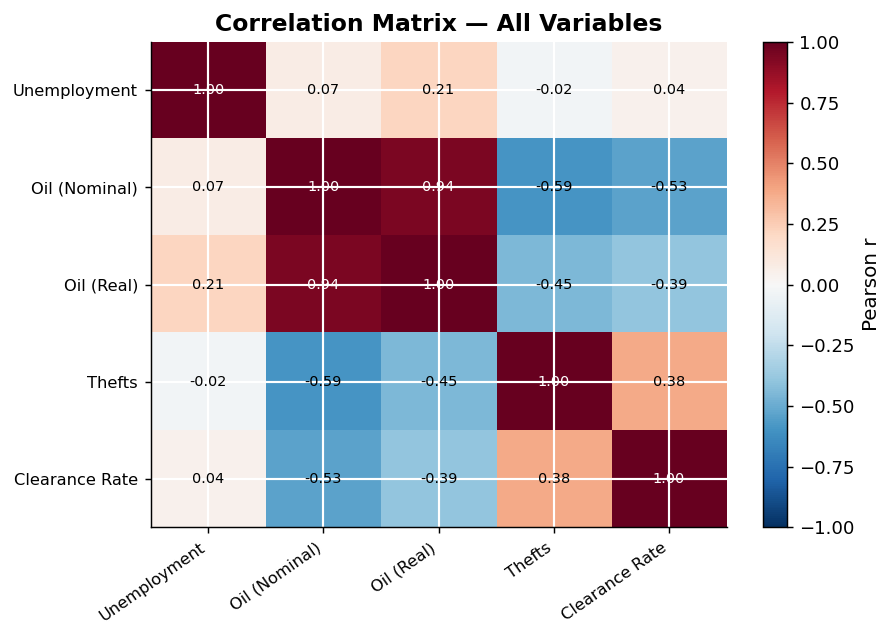

In [19]:
# ── Pearson correlations ──────────────────────────────────────────────────────
corr = merged.corr(method='pearson').round(3)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

labels = ['Unemployment', 'Oil (Nominal)', 'Oil (Real)', 'Thefts', 'Clearance Rate']
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i,j]) > 0.6 else 'black')

ax.set_title('Correlation Matrix — All Variables', fontweight='bold')
plt.tight_layout()
plt.show()


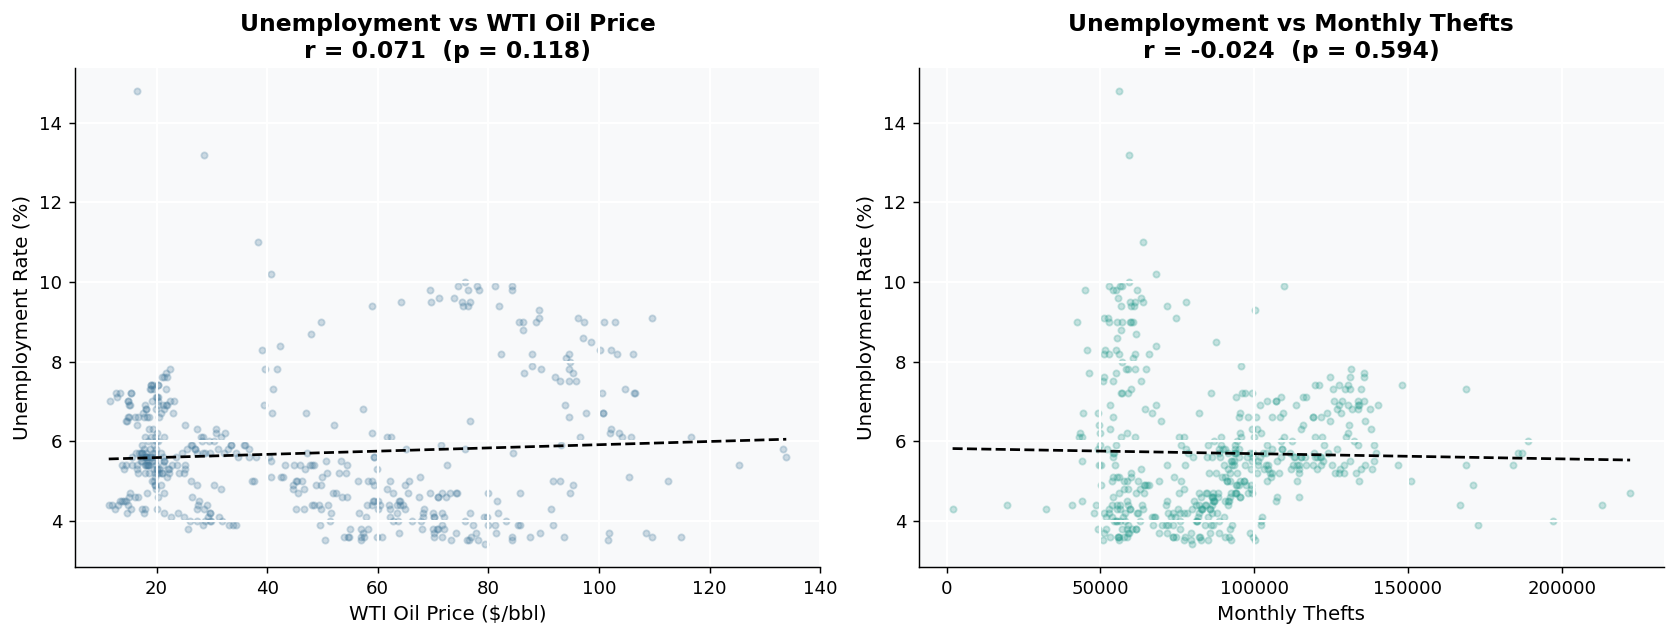

In [20]:
# ── Scatter: Unemployment vs. Oil (nominal) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, xcol, xlabel, color in [
    (axes[0], 'oil_price', 'WTI Oil Price ($/bbl)',     COLORS['oil']),
    (axes[1], 'theft_offenses', 'Monthly Thefts',       COLORS['theft']),
]:
    ax.scatter(merged[xcol], merged['unrate'], alpha=0.25, s=12, color=color)
    slope, intercept, r, p, _ = stats.linregress(merged[xcol], merged['unrate'])
    xline = np.linspace(merged[xcol].min(), merged[xcol].max(), 200)
    ax.plot(xline, slope*xline + intercept, color='black', lw=1.5, ls='--')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Unemployment Rate (%)')
    ax.set_title(f'Unemployment vs {xlabel.split("(")[0].strip()}\nr = {r:.3f}  (p = {p:.3g})',
                 fontweight='bold')

plt.tight_layout()
plt.show()


## 8. Recession Overlay

NBER U.S. recession periods shaded in grey for context.


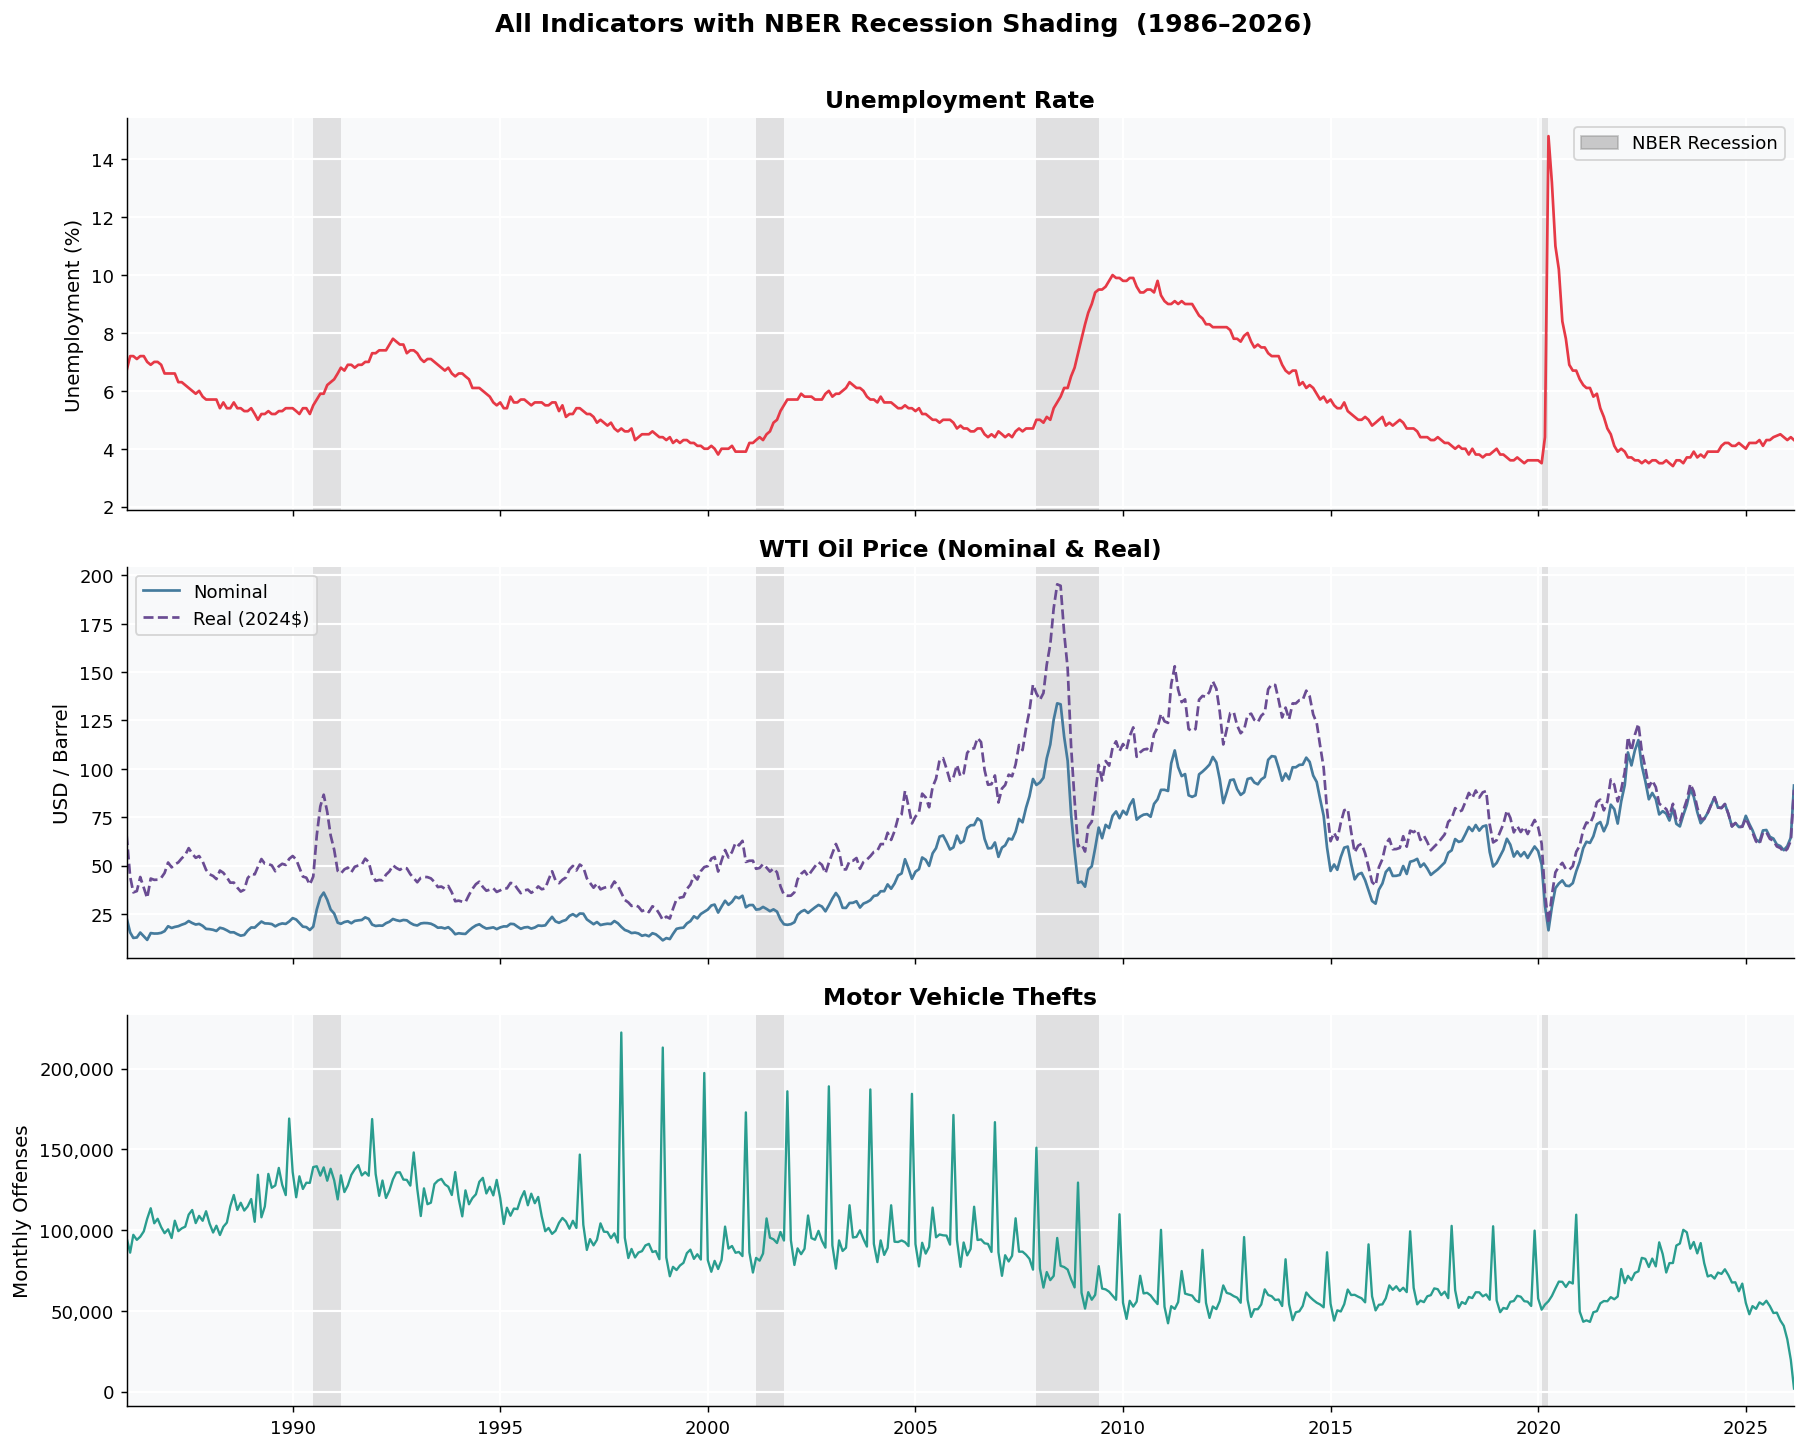

In [21]:
# NBER recession periods (start, end)
recessions = [
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),
]

def shade_recessions(ax, recessions):
    for start, end in recessions:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color='grey', alpha=0.2, lw=0, label='_nolegend_')

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

for ax in axes:
    shade_recessions(ax, recessions)

# Unemployment
axes[0].plot(unrate.index, unrate['unrate'], color=COLORS['unrate'], lw=1.5)
axes[0].set_ylabel('Unemployment (%)')
axes[0].set_title('Unemployment Rate', fontweight='bold')

# Oil (nominal + real)
axes[1].plot(oil_real.index, oil_real['oil_price'], color=COLORS['oil'],  lw=1.5, label='Nominal')
axes[1].plot(oil_real.index, oil_real['oil_real'],  color=COLORS['real'], lw=1.5, ls='--', label='Real (2024$)')
axes[1].set_ylabel('USD / Barrel')
axes[1].set_title('WTI Oil Price (Nominal & Real)', fontweight='bold')
axes[1].legend(loc='upper left')

# Theft
axes[2].plot(theft.index, theft['theft_offenses'], color=COLORS['theft'], lw=1.3)
axes[2].set_ylabel('Monthly Offenses')
axes[2].set_title('Motor Vehicle Thefts', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].set_xlim(pd.Timestamp('1986-01-01'), theft.index.max())

# Add a single recession patch to legend
import matplotlib.patches as mpatches
rec_patch = mpatches.Patch(color='grey', alpha=0.4, label='NBER Recession')
axes[0].legend(handles=[rec_patch], loc='upper right')

fig.suptitle('All Indicators with NBER Recession Shading  (1986–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
